# PCD Assignment 01. Down Sampling dan Up Sampling Citra

Notebook ini berisi program untuk dua topik.

1. Down Sampling. Menggunakan metode Max, Average, dan Median.
2. Up Sampling. Menggunakan metode Nearest Neighbor, Bilinear, dan Bicubic.

Beberapa gambar dengan karakteristik berbeda digunakan sebagai input, supaya efek dari setiap metode bisa dianalisis dengan lebih jelas.

Cara pakai di Google Colab. Buka notebook ini, lalu jalankan semua cell dari atas ke bawah lewat menu Runtime kemudian Run all.

## 1. Persiapan

In [12]:
# Baris ini memastikan semua library yang dibutuhkan sudah terpasang
!pip install -q opencv-python-headless scikit-image matplotlib pandas numpy

In [13]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd

from skimage import data, img_as_ubyte
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

os.makedirs("images", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

plt.rcParams["figure.facecolor"] = "white"

## 2. Gambar yang Digunakan

Ada empat gambar dengan karakteristik berbeda.

1. Gambar natural (astronaut). Ini adalah foto biasa dengan warna dan tekstur campuran.
2. Gambar dengan tepi tegas (camera). Foto hitam putih yang punya garis dan detail halus.
3. Gambar frekuensi tinggi (checkerboard). Pola kotak kotak yang berulang dan tajam.
4. Gambar halus (gradient). Gambar buatan yang perubahan warnanya pelan dan lembut.

Semua gambar dibuat langsung lewat kode di bawah ini, jadi notebook bisa langsung dijalankan tanpa perlu upload file apapun.

In [14]:
astronaut = img_as_ubyte(data.astronaut())
cv2.imwrite("images/img_natural_astronaut.png", cv2.cvtColor(astronaut, cv2.COLOR_RGB2BGR))

camera = img_as_ubyte(data.camera())
cv2.imwrite("images/img_edges_camera.png", camera)

checker = img_as_ubyte(data.checkerboard())
checker = cv2.resize(checker, (512, 512), interpolation=cv2.INTER_NEAREST)
cv2.imwrite("images/img_highfreq_checkerboard.png", checker)

h, w = 512, 512
x = np.linspace(0, 1, w)
y = np.linspace(0, 1, h)
xx, yy = np.meshgrid(x, y)
gradient = 0.5 * (np.sin(6 * np.pi * xx) + 1) * 0.5 + 0.5 * yy
gradient = (gradient * 255).astype(np.uint8)
cv2.imwrite("images/img_smooth_gradient.png", gradient)

IMAGES = {
    "natural (astronaut)": "images/img_natural_astronaut.png",
    "tepi tegas (camera)": "images/img_edges_camera.png",
    "frekuensi tinggi (checkerboard)": "images/img_highfreq_checkerboard.png",
    "halus (gradient)": "images/img_smooth_gradient.png",
}
print("Gambar tersimpan di folder images.")

Gambar tersimpan di folder images.


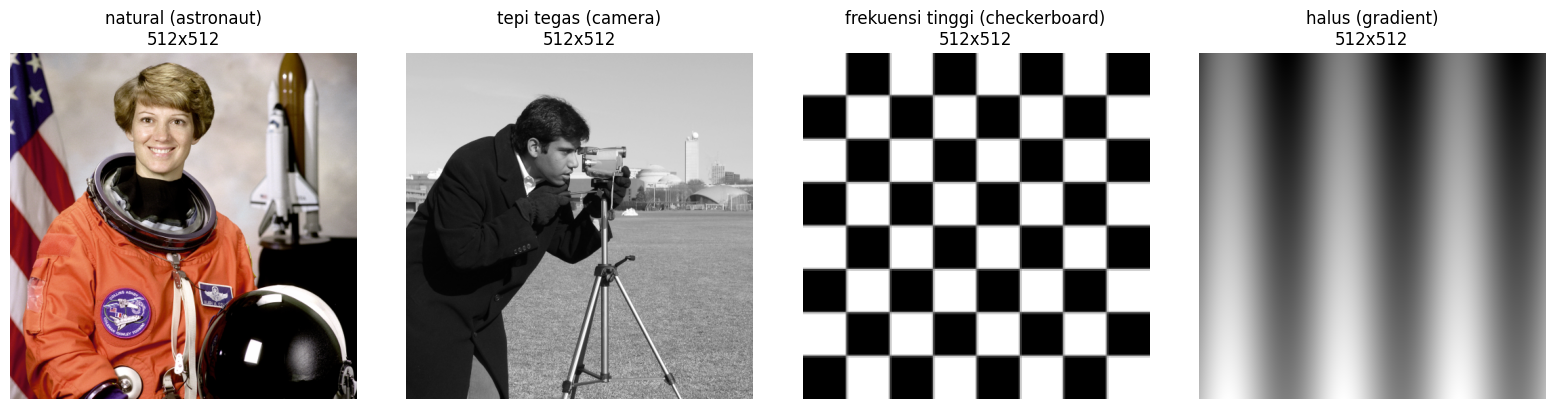

In [15]:
def to_rgb(img):
    if img.ndim == 2:
        return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, len(IMAGES), figsize=(4 * len(IMAGES), 4))
for ax, (label, path) in zip(axes, IMAGES.items()):
    im = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    ax.imshow(to_rgb(im))
    ax.set_title(f"{label}\n{im.shape[1]}x{im.shape[0]}")
    ax.axis("off")
plt.tight_layout()
plt.savefig("outputs/00_gambar_uji.png", dpi=110)
plt.show()

## 3. Down Sampling. Max, Average, Median

Down sampling artinya memperkecil ukuran gambar. Caranya, gambar dibagi menjadi blok blok kecil misalnya ukuran 4 kali 4 piksel, lalu setiap blok diubah menjadi satu piksel saja.

Ada tiga cara mengambil nilai dari satu blok.

1. Max pooling. Mengambil nilai paling terang dari blok tersebut.
2. Average pooling. Mengambil nilai rata rata dari blok tersebut.
3. Median pooling. Mengambil nilai tengah setelah semua nilai di blok diurutkan.

In [16]:
def downsample(img, factor, method="average"):
    h, w = img.shape[:2]
    nh, nw = h // factor, w // factor
    h_c, w_c = nh * factor, nw * factor
    cropped = img[:h_c, :w_c]

    if cropped.ndim == 2:
        blocks = cropped.reshape(nh, factor, nw, factor)
    else:
        c = cropped.shape[2]
        blocks = cropped.reshape(nh, factor, nw, factor, c)
    axis = (1, 3)

    if method == "max":
        out = blocks.max(axis=axis)
    elif method == "average":
        out = blocks.mean(axis=axis)
    elif method == "median":
        out = np.median(blocks, axis=axis)
    else:
        raise ValueError(f"Metode tidak dikenal, {method}")
    return out.astype(img.dtype)

## 4. Hasil Down Sampling

Setiap gambar diperkecil 4 kali menggunakan tiga metode di atas, lalu hasilnya dibandingkan langsung dengan gambar aslinya secara visual.

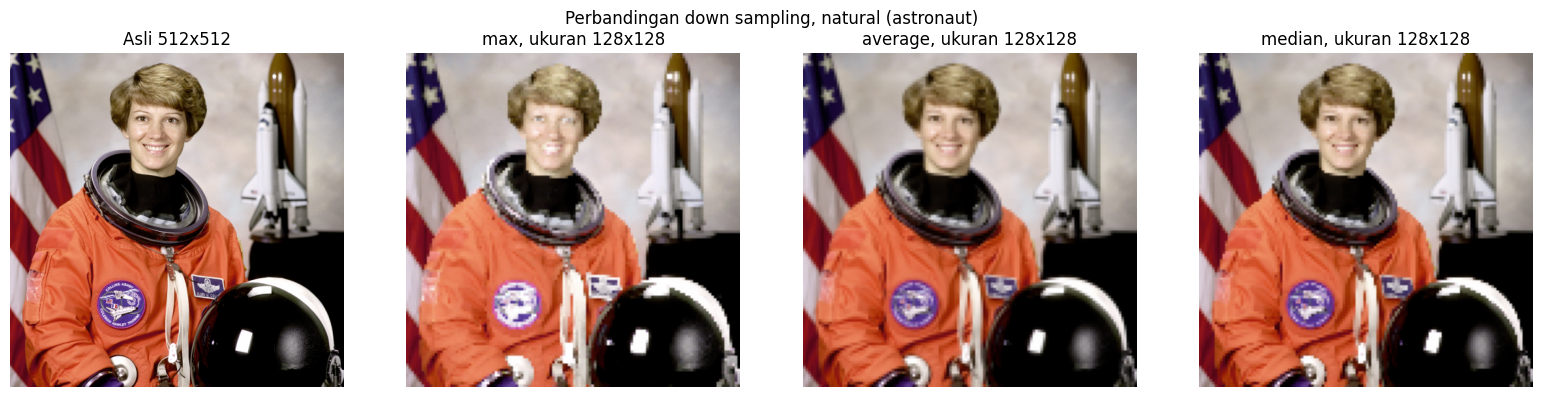

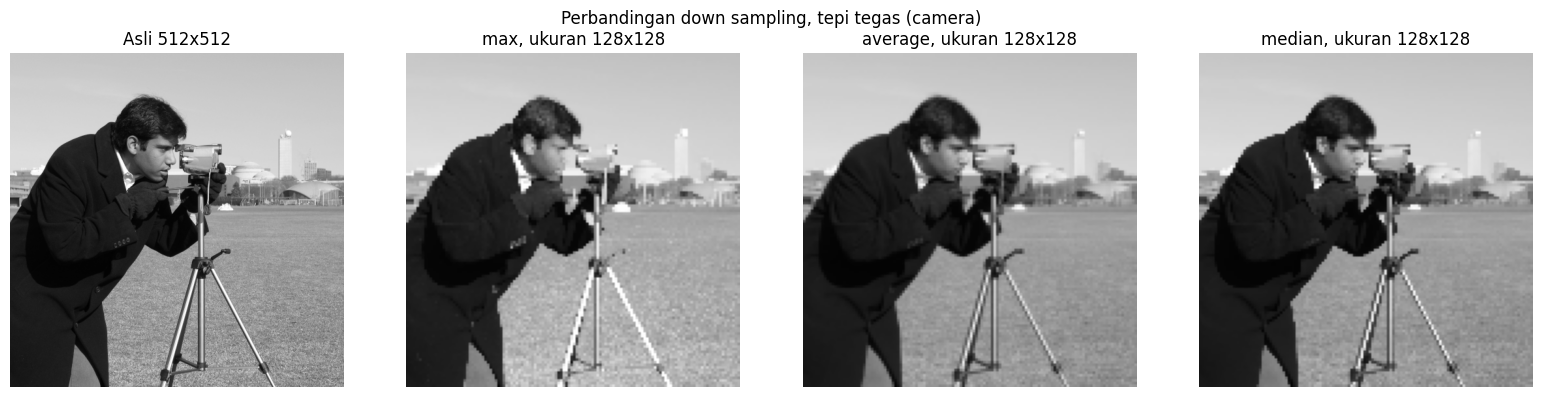

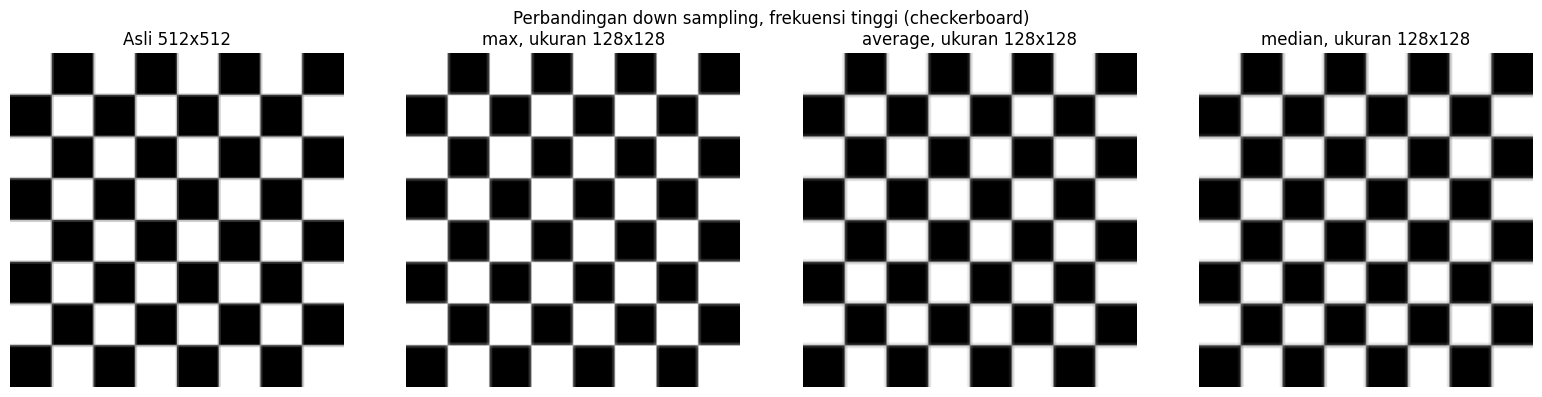

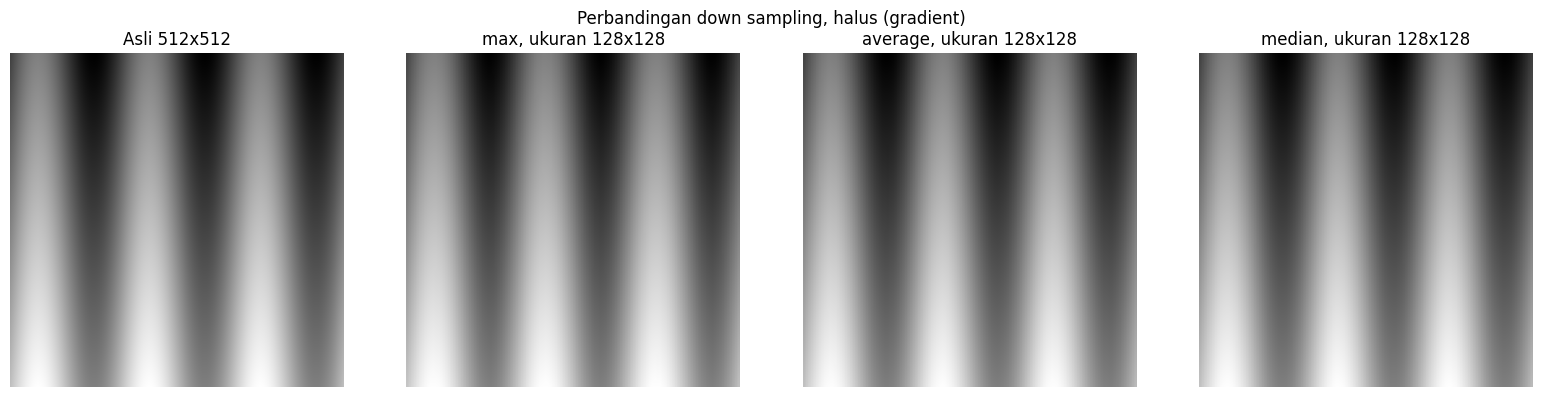

In [17]:
FAKTOR_KECIL = 4
METODE_DOWN = ["max", "average", "median"]

hasil_down = {}

for label, path in IMAGES.items():
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    H, W = img.shape[:2]

    fig, axes = plt.subplots(1, len(METODE_DOWN) + 1, figsize=(4 * (len(METODE_DOWN) + 1), 4))
    axes[0].imshow(to_rgb(img))
    axes[0].set_title(f"Asli {W}x{H}")
    axes[0].axis("off")

    kecil = {}
    for i, m in enumerate(METODE_DOWN, start=1):
        small = downsample(img, FAKTOR_KECIL, m)
        kecil[m] = small
        axes[i].imshow(to_rgb(small))
        axes[i].set_title(f"{m}, ukuran {small.shape[1]}x{small.shape[0]}")
        axes[i].axis("off")

    hasil_down[label] = kecil
    fig.suptitle(f"Perbandingan down sampling, {label}")
    fig.tight_layout()
    nama_file = label.split()[0].strip("()")
    fig.savefig(f"outputs/{nama_file}_downsampling.png", dpi=110)
    plt.show()

## 5. Up Sampling. Nearest Neighbor, Bilinear, Bicubic

Up sampling artinya memperbesar ukuran gambar. Di bagian ini, gambar uji langsung diperbesar dari ukurannya sekarang, tanpa melalui proses down sampling terlebih dahulu. Jadi cara penyajiannya sama seperti bagian down sampling di atas, hanya arahnya dibalik.

Supaya efek dari setiap metode terlihat jelas, gambar dipotong kecil dulu bagian tertentu saja, baru bagian kecil itu diperbesar 4 kali. Ada tiga cara untuk mengisi piksel piksel baru yang muncul saat gambar diperbesar.

1. Nearest Neighbor. Piksel baru diisi dengan nilai piksel terdekat yang sudah ada. Caranya paling sederhana, tapi hasilnya terlihat kotak kotak.
2. Bilinear. Piksel baru dihitung dari empat piksel terdekat, dengan cara interpolasi garis lurus. Hasilnya lebih halus dibanding Nearest Neighbor.
3. Bicubic. Piksel baru dihitung dari enam belas piksel di sekitarnya, dengan rumus kurva. Hasilnya biasanya paling halus dan paling detail dibanding dua metode lainnya.

In [18]:
def upsample(img, size, method="bilinear"):
    interp = {
        "nn": cv2.INTER_NEAREST,
        "bilinear": cv2.INTER_LINEAR,
        "bicubic": cv2.INTER_CUBIC,
    }[method]
    return cv2.resize(img, size, interpolation=interp)

## 6. Hasil Up Sampling

Setiap gambar uji dipotong pada bagian yang punya tepi jelas, kemudian potongan kecil itu diperbesar 4 kali dengan tiga metode di atas. Hasilnya dibandingkan langsung secara visual, sama seperti cara membandingkan hasil down sampling.

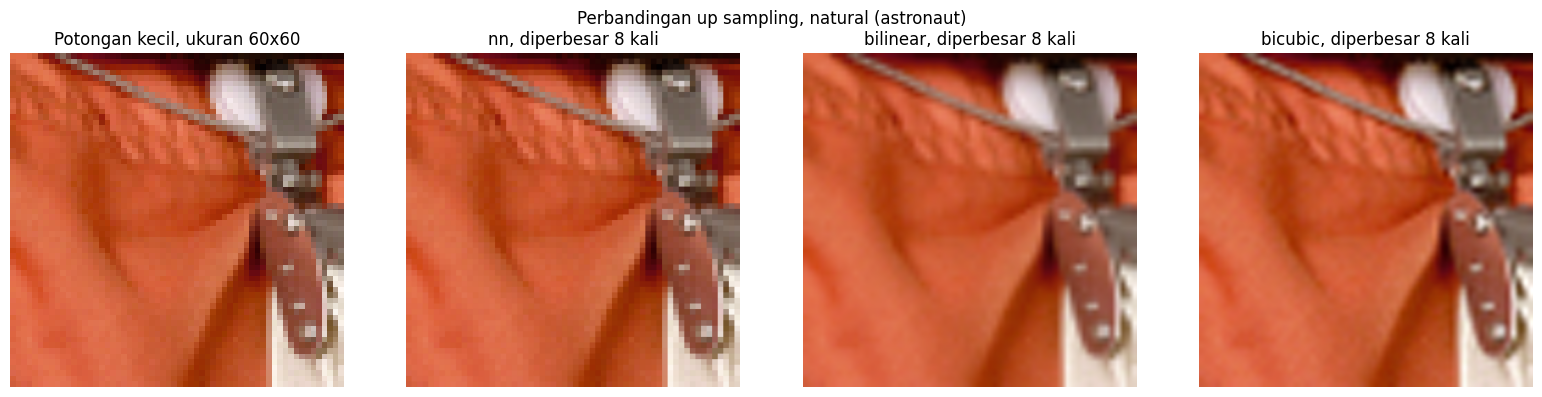

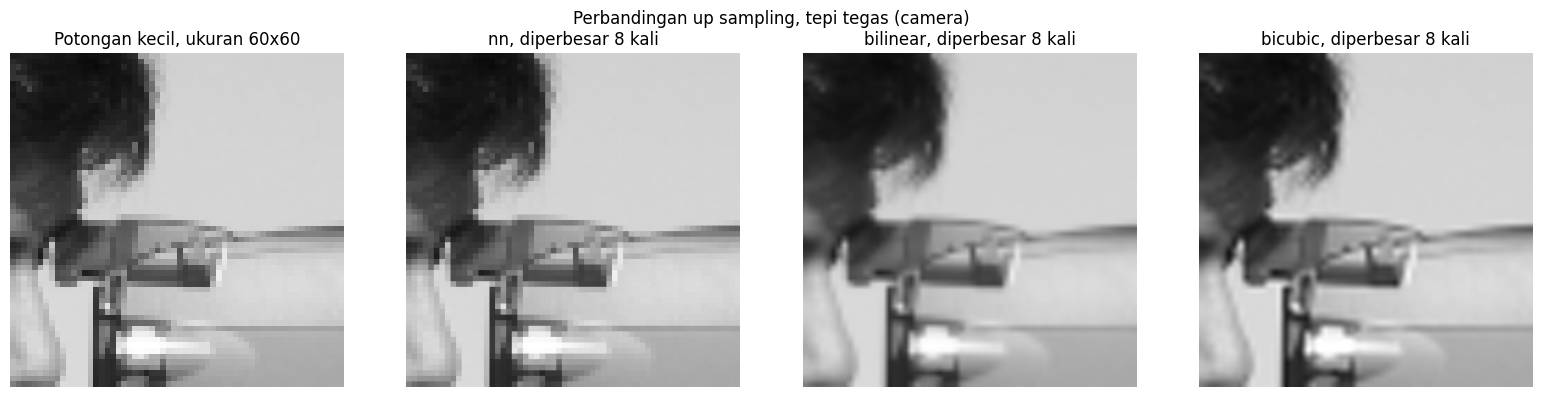

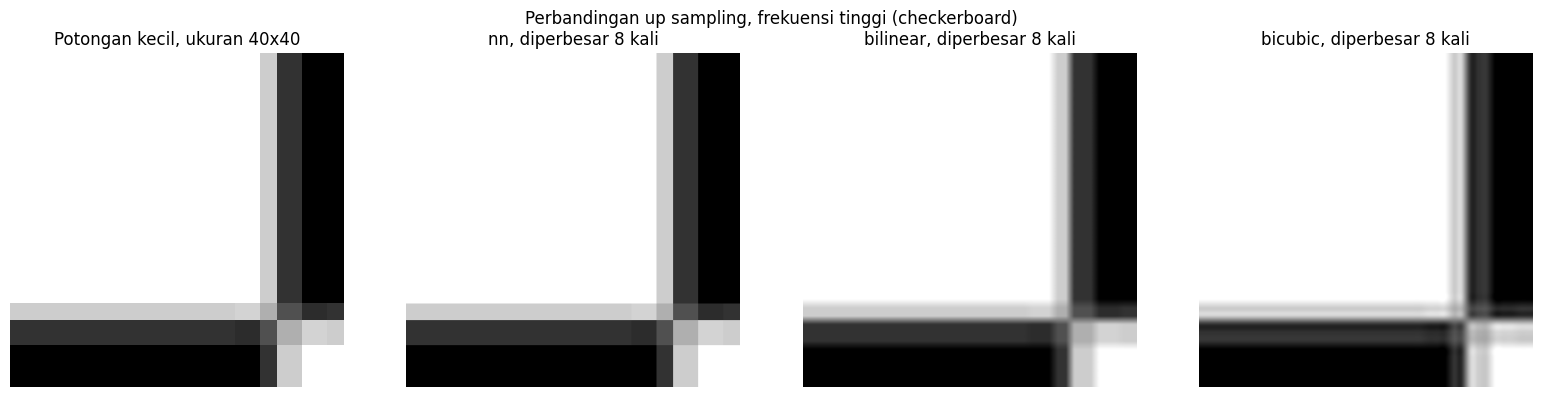

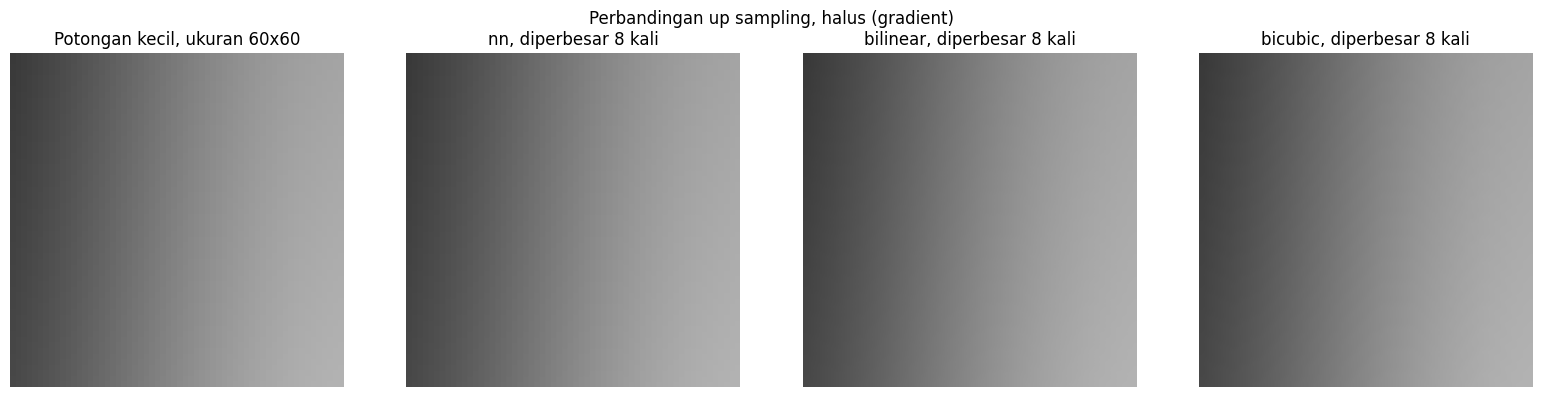

In [19]:
FAKTOR_BESAR = 8
METODE_UP = ["nn", "bilinear", "bicubic"]

area_potong = {
    "natural (astronaut)": (295, 355, 195, 255),
    "tepi tegas (camera)": (110, 170, 245, 305),
    "frekuensi tinggi (checkerboard)": (160, 200, 160, 200),
    "halus (gradient)": (150, 210, 150, 210),
}

for label, path in IMAGES.items():
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    y1, y2, x1, x2 = area_potong[label]
    potongan = img[y1:y2, x1:x2]
    ph, pw = potongan.shape[:2]

    fig, axes = plt.subplots(1, len(METODE_UP) + 1, figsize=(4 * (len(METODE_UP) + 1), 4))
    axes[0].imshow(to_rgb(potongan))
    axes[0].set_title(f"Potongan kecil, ukuran {pw}x{ph}")
    axes[0].axis("off")

    for i, m in enumerate(METODE_UP, start=1):
        besar = upsample(potongan, (pw * FAKTOR_BESAR, ph * FAKTOR_BESAR), m)
        axes[i].imshow(to_rgb(besar))
        axes[i].set_title(f"{m}, diperbesar {FAKTOR_BESAR} kali")
        axes[i].axis("off")

    fig.suptitle(f"Perbandingan up sampling, {label}")
    fig.tight_layout()
    nama_file = label.split()[0].strip("()")
    fig.savefig(f"outputs/{nama_file}_upsampling.png", dpi=110)
    plt.show()

## 7. Pengujian Tambahan. Mengukur Angka Kualitas Up Sampling

Bagian di atas hanya menilai up sampling secara visual saja, karena gambar yang diperbesar tidak punya pembanding yang pasti. Piksel piksel baru itu memang belum pernah ada sebelumnya, jadi tidak ada cara untuk mengukur seberapa benar hasilnya dengan angka.

Untuk memberi angka, dipakai cara berbeda. Gambar asli diperkecil dulu, baru diperbesar lagi ke ukuran semula. Karena gambar aslinya masih ada, hasil perbesaran itu bisa dibandingkan langsung dengan gambar asli menggunakan dua ukuran, yaitu PSNR dan SSIM. Semakin besar angkanya, semakin dekat hasilnya dengan gambar asli.

In [20]:
hasil_metrik = []

for label, path in IMAGES.items():
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    H, W = img.shape[:2]
    kecil = hasil_down[label]["average"]

    for m in METODE_UP:
        besar = upsample(kecil, (W, H), m)
        p = psnr(img, besar, data_range=255)
        s = ssim(img, besar, channel_axis=2 if img.ndim == 3 else None)
        hasil_metrik.append({
            "gambar": label,
            "metode_down": "average",
            "metode_up": m,
            "PSNR_dB": round(p, 2),
            "SSIM": round(s, 3),
        })

metrik_df = pd.DataFrame(hasil_metrik)
metrik_df.to_csv("outputs/tabel_metrik.csv", index=False)
metrik_df

,gambar,metode_down,metode_up,PSNR_dB,SSIM
0,natural (astronaut),average,nn,23.39,0.784
1,natural (astronaut),average,bilinear,24.56,0.809
2,natural (astronaut),average,bicubic,25.57,0.839
3,tepi tegas (camera),average,nn,25.16,0.750
4,tepi tegas (camera),average,bilinear,25.67,0.745
5,tepi tegas (camera),average,bicubic,26.37,0.763
6,frekuensi tinggi (checkerboard),average,nn,27.57,0.893
7,frekuensi tinggi (checkerboard),average,bilinear,24.95,0.887
8,frekuensi tinggi (checkerboard),average,bicubic,25.70,0.954
9,halus (gradient),average,nn,42.19,0.962


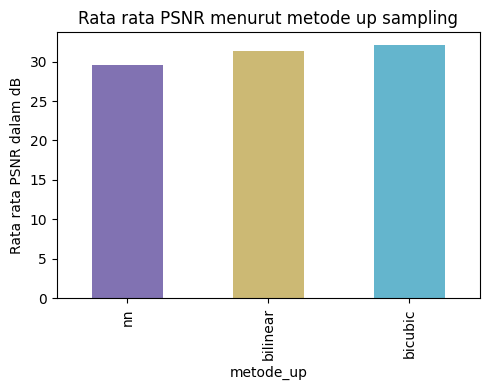

In [21]:
pivot = metrik_df.groupby("metode_up")["PSNR_dB"].mean().reindex(METODE_UP)
plt.figure(figsize=(5, 4))
pivot.plot(kind="bar", color=["#8172B2", "#CCB974", "#64B5CD"])
plt.ylabel("Rata rata PSNR dalam dB")
plt.title("Rata rata PSNR menurut metode up sampling")
plt.tight_layout()
plt.savefig("outputs/grafik_psnr_up.png", dpi=110)
plt.show()

## 8. Analisis

**Down Sampling**

Max pooling membuat gambar terlihat lebih terang dari aslinya karena metode ini selalu mengambil nilai paling terang dari setiap blok. Detail gelap jadi hilang dan hasilnya terlihat kurang alami dibanding dua metode lainnya.

Average pooling menghasilkan gambar yang lebih halus dan warnanya masih mendekati aslinya. Cara ini seperti menghaluskan gambar dulu sebelum diperkecil sehingga informasi yang hilang lebih sedikit.

Median pooling hasilnya mirip dengan average pooling pada gambar biasa. Kelebihan median terlihat kalau gambarnya punya noise, misalnya ada titik titik terang atau gelap yang tidak wajar. Median tidak mudah terpengaruh oleh nilai nilai ekstrim seperti itu, sedangkan average bisa ikut bergeser karena nilai ekstrim tersebut.

Pada gambar checkerboard yang polanya sangat rapat, semua metode down sampling sama sama kehilangan detail karena ukuran hasil yang lebih kecil memang sudah tidak cukup untuk menyimpan pola serapat itu.

**Up Sampling**

Nearest Neighbor menghasilkan gambar yang terlihat kotak kotak, terutama kalau diperbesar dan dilihat dari dekat. Cara ini paling cepat tapi kurang halus.

Bilinear menghasilkan gambar yang lebih halus dibanding Nearest Neighbor. Tepi tepi pada gambar tidak lagi terlihat seperti tangga, tapi sedikit lebih buram dibanding aslinya.

Bicubic menghasilkan gambar paling halus dan detailnya paling terjaga di antara tiga metode. Prosesnya sedikit lebih berat karena menghitung dari area yang lebih luas.

Khusus untuk gambar checkerboard, Nearest Neighbor kadang malah terlihat lebih tajam dibanding bilinear atau bicubic. Ini terjadi karena pola pada checkerboard berbentuk kotak kotak lurus yang sejajar dengan piksel, jadi mengambil piksel terdekat justru menjaga bentuk kotaknya tetap tajam, sedangkan bilinear dan bicubic malah membuat tepinya jadi buram.

**Kesimpulan**

Untuk memperkecil foto biasa, average atau median pooling lebih disarankan dibanding max pooling.

Median pooling lebih cocok dipakai kalau gambarnya mengandung noise.

Untuk memperbesar foto biasa, bicubic memberikan hasil paling baik, diikuti bilinear, lalu Nearest Neighbor.

Untuk memperbesar gambar dengan garis lurus dan kotak kotak tegas, Nearest Neighbor bisa jadi pilihan yang lebih baik karena tidak membuat tepinya buram.

Down sampling adalah proses yang menghilangkan sebagian informasi gambar. Proses up sampling sesudahnya hanya bisa menebak kembali nilai piksel yang hilang tersebut dan tidak bisa mengembalikan gambar persis seperti aslinya.

## 9. Berkas yang Dihasilkan

1. Folder images, berisi empat gambar uji.
2. Folder outputs, berisi semua gambar hasil perbandingan dan file tabel_metrik.csv.
3. REPORT.md, berisi laporan analisis dalam bentuk tulisan.

## Referensi

1. Gonzalez dan Woods, Digital Image Processing, edisi keempat.
2. Dokumentasi OpenCV mengenai fungsi resize dan pilihan metode interpolasinya. https://docs.opencv.org/4.x/da/d54/group__imgproc__transform.html
3. Dokumentasi scikit image mengenai metrics, khususnya PSNR dan SSIM. https://scikit-image.org/docs/stable/api/skimage.metrics.html